In [5]:
import gymnasium as gym
import numpy as np

from q_learning import EpsilonGreedy, Qlearning
from quantile_regression import QuantileRegression
from dist_run import Params, run_env, save_experiment, load_experiment
from envs.register import register_envs

register_envs()

params = Params(
    model_name="Simple-v1",
    total_episodes=30_000,
    save_skip=100,
    n_runs=1,
    seed=123,
    
    use_lr_decay=True,
    decay_rate=1e-3,
    learning_rate=1.0,

    gamma=1.0,
    epsilon=1.0,
    huber_k=1.0,
    n_quantiles=256,
    
    action_size=None,
    state_size=None,
    map_size=None,
)
rng = np.random.default_rng(params.seed)

env = gym.make(params.model_name)
params = params._replace(action_size=int(env.action_space.n))
params = params._replace(state_size=int(env.observation_space.n))
params = params._replace(map_size=env.unwrapped.shape)
env.action_space.seed(params.seed);

In [4]:
learner = QuantileRegression(params)
explorer = EpsilonGreedy(params.epsilon, rng)
tables_run = run_env(env, learner, explorer, params, show_progress=False)
save_experiment(tables_run, params)

Run 0/1 - Episodes:  27%|██▋       | 7951/30000 [00:02<00:07, 3045.13it/s]


KeyboardInterrupt: 

In [ ]:
params, tables = load_experiment("Simple-v1_prime")
tables = tables.mean(0)
qtables = tables.mean(-1) if params.n_quantiles > 1 else tables[-1]
qtable = qtables[-1]

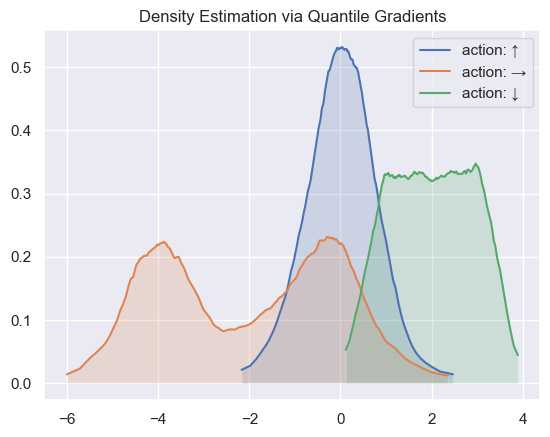

In [3]:
from analysis import plot_grad
plot_grad(tables[-1, 4], params)